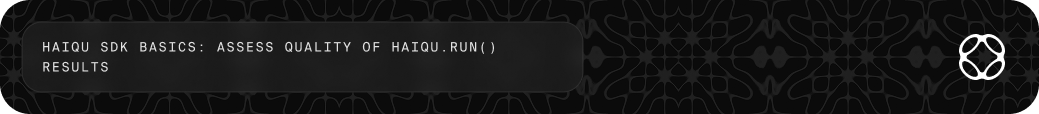

This notebook demonstrates how to assess the quality of `haiqu.run()` results on noisy devices and simulators.

- For **sampling tasks**, quality is reported as **Hellinger fidelity** between the noisy and ideal distributions.
- For **observable estimation tasks**, quality is reported as **1 − relative error** against the statevector reference.
- When multiple circuits are submitted, per-circuit metrics are available in `job.info["quality_assessment"]["per_circuit"]`.
- Quality assessment requires a statevector simulation reference — it is skipped automatically for circuits above 20 qubits.

### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

### `job.quality`

- **What does it measure?** Quality estimates how closely the noisy device result matches the ideal (statevector) result — always between 0 and 1, where 1 is perfect.
- **Sampling task metric:** **Hellinger fidelity** — compares the measured probability distribution to the ideal distribution. Higher is better.
- **Observable task metric:** **1 − relative error** — measures how close the estimated expectation value is to the ideal value. Higher is better.
- **Per-circuit breakdown:** For multi-circuit jobs, individual circuit metrics are available in `job.info["quality_assessment"]["per_circuit"]`.

**Note:** this notebook assumes some basic knowledge of Haiqu SDK. Make sure to read through [`haiqu_run.ipynb`](./haiqu_run.ipynb) notebook first.

## Initialize the example

Import the necessary libraries, initialize the Haiqu SDK, and configure the target device. We use `fake_geneva` as a noisy simulator by default — you can swap it for any real IBM backend.

In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp

from haiqu.sdk import haiqu,set_haiqu_mpl_style

haiqu.login()
haiqu.init("Quality Estimate Tutorial")
set_haiqu_mpl_style()

In [2]:
haiqu.list_simulators()

Vendor,Quantum System,Qubits,Status,Queue Length
IBM,aer_simulator,1024,online,0
IBM,fake_fez,156,online,0
IBM,fake_marrakesh,156,online,0
IBM,fake_torino,133,online,0
IBM,fake_kyoto,127,online,0
IBM,fake_washington,127,online,0
IBM,fake_kyiv,127,online,0
IBM,fake_sherbrooke,127,online,0
IBM,fake_brisbane,127,online,0
IBM,fake_quebec,127,online,0


In [3]:
# Device setup — use a noisy fake backend for reproducible quality metrics
device = haiqu.get_device("fake_geneva")
options = {}

# Uncomment the following lines to run on the actual IBM Quantum device
# device = haiqu.get_device("ibm_torino")
# options = {
#     "ibm_quantum_token": "YOUR_IBM_QUANTUM_TOKEN",
#     "ibm_quantum_instance": "YOUR_IBM_QUANTUM_INSTANCE_ID",
# }

## Example 1: Sampling quality (Hellinger fidelity)

Run a measured Bell-state circuit and inspect the quality score. For sampling tasks, Haiqu computes the Hellinger fidelity between the noisy output distribution and the ideal statevector distribution.

### Submit Job

In [4]:
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()

job1 = haiqu.run(
    bell,
    device=device,
    shots=1024,
    options=options,
)
saved_job1_id = job1.id
print(f"Job ID: {saved_job1_id}")

Job ID: jb-0ca96af9-dfe5-4fe7-ba34-538db7d09934


### Retrieve Results

Run this cell once the job is complete. For real QPU jobs, this may take minutes to hours. You can close the notebook and come back later—just use the saved job ID to retrieve results.

**Note:** `job.result()` is a blocking call. If the job is not complete, it will wait until results are ready.

In [5]:
def print_quality(job):
    print(f"job_id   : {job.id}")
    print(f"status   : {job.status}")
    print(f"quality  : {job.quality}")

    qa = None
    if getattr(job, "info", None):
        qa = job.info.get("quality_assessment")

    if qa is None:
        print("quality_assessment: N/A")
        return

    print("quality_assessment:")
    print(qa)

In [6]:
job1 = haiqu.get_job(saved_job1_id)
result1 = job1.result()
print_quality(job1)

job_id   : jb-0ca96af9-dfe5-4fe7-ba34-538db7d09934
status   : JobStatus.DONE
quality  : 0.96938986098503
quality_assessment:
{'per_circuit': {'circ-a355f9ce-53cf-442d-82d4-f1b11e805e9c': 0.96938986098503}}


## Example 2: Fidelity decay vs circuit size (with and without mitigation)

Run two multi-circuit jobs with increasingly large GHZ state preparation circuits (2 to 12 qubits): one baseline and one with `use_mitigation=True`. Compare how Hellinger fidelity degrades with circuit size and how mitigation recovers it.

### Submit Jobs

In [7]:
def ghz_circuit(num_qubits: int) -> QuantumCircuit:
    qc = QuantumCircuit(num_qubits)
    qc.h(0)
    for q in range(1, num_qubits):
        qc.cx(0, q)
    qc.measure_all()
    return qc

In [8]:
qubit_sizes = list(range(2, 13))
ghz_circuits = [ghz_circuit(n) for n in qubit_sizes]

# Baseline run (no mitigation)
job2_base = haiqu.run(
    ghz_circuits,
    device=device,
    shots=1024,
    options=options,
    use_mitigation=False,
)
saved_job2_base_id = job2_base.id

# Mitigated run
job2_mit = haiqu.run(
    ghz_circuits,
    device=device,
    shots=1024,
    options=options,
    use_mitigation=True,
)
saved_job2_mit_id = job2_mit.id

print(f"Baseline job ID:  {saved_job2_base_id}")
print(f"Mitigated job ID: {saved_job2_mit_id}")

Baseline job ID:  jb-682b7838-8637-4727-a3eb-b5063baf869e
Mitigated job ID: jb-20048da7-5893-4abf-abdd-0c2e420c9d3a


### Retrieve Results

Run this cell once both jobs are complete. You can close the notebook and come back later—just use the saved job IDs to retrieve results.

In [9]:
import matplotlib.pyplot as plt

def plot_quality(qubit_sizes, fidelities_base, fidelities_mit):
    plt.figure(figsize=(7, 4))
    plt.plot(qubit_sizes, fidelities_mit, marker="s", linewidth=2, label="With mitigation")
    plt.plot(qubit_sizes, fidelities_base, marker="o", linewidth=2, label="No mitigation")
    plt.xlabel("Number of Qubits")
    plt.ylabel("Hellinger Fidelity")
    plt.title("Quality Decay for GHZ State Preparation")
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1.05)
    plt.legend()
    plt.show()

Baseline run:
job_id   : jb-682b7838-8637-4727-a3eb-b5063baf869e
status   : JobStatus.DONE
quality  : 0.7147356714155412
quality_assessment:
{'per_circuit': {'circ-a355f9ce-53cf-442d-82d4-f1b11e805e9c': 0.9559227485660913, 'circ-1d4a7851-034a-4960-b430-c6eb4602e354': 0.9218087876172696, 'circ-2430c632-36b5-4676-8025-ad04d404f70c': 0.8925610294865747, 'circ-05b6874e-6a88-430d-9b90-6bf830ea45c6': 0.8563869937876308, 'circ-0dfd6252-cccc-4f8f-94f5-d4e6af6d3402': 0.802258880448479, 'circ-21f127c6-93b6-490f-b1eb-eeabb47f9d01': 0.6013706140155576, 'circ-c54c27f3-bfe4-4095-8dae-e8aac2766a04': 0.7147356714155412, 'circ-d298ed2f-b7bf-469b-adcc-10e34f69a980': 0.5509576858040351, 'circ-070edd6b-ec11-49c2-9a7e-75d20e87b33c': 0.5165457133324884, 'circ-9fe86ff6-be71-49bc-88e0-05248a8706ad': 0.5045874987787937, 'circ-3d23e53b-cab6-4ac2-a915-56c26d5ec86a': 0.5222194232576572}}

Mitigated run:
job_id   : jb-20048da7-5893-4abf-abdd-0c2e420c9d3a
status   : JobStatus.DONE
quality  : 0.9636036779813003
qual

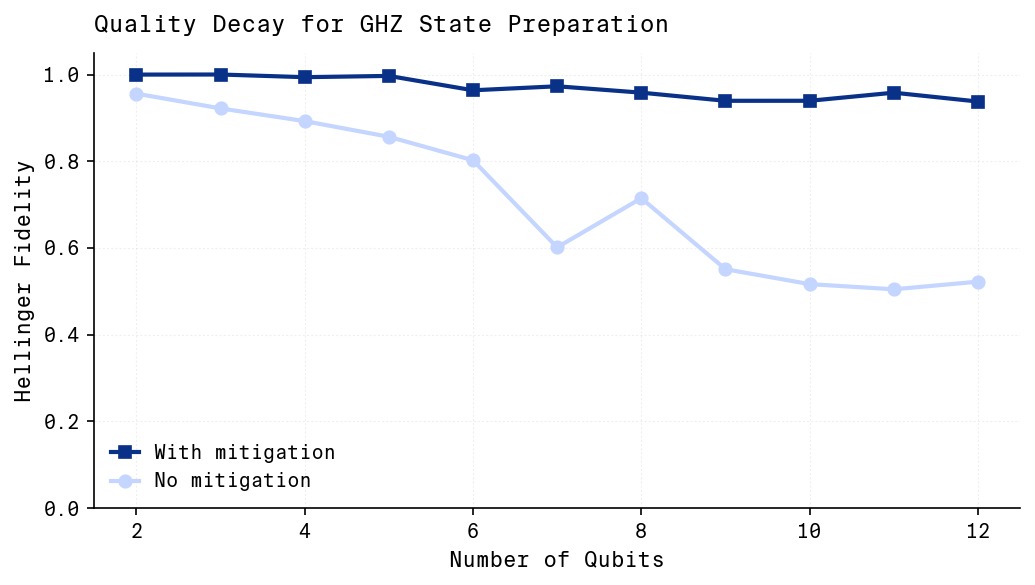

In [10]:
job2_base = haiqu.get_job(saved_job2_base_id)
job2_mit = haiqu.get_job(saved_job2_mit_id)

_ = job2_base.result()
_ = job2_mit.result()

print("Baseline run:")
print_quality(job2_base)
print("\nMitigated run:")
print_quality(job2_mit)

qa_base = (job2_base.info or {}).get("quality_assessment", {})
per_circuit_base = qa_base.get("per_circuit", {})
fidelities_base = [per_circuit_base.get(circuit_id, float("nan")) for circuit_id in job2_base.circuit_ids]

qa_mit = (job2_mit.info or {}).get("quality_assessment", {})
per_circuit_mit = qa_mit.get("per_circuit", {})
fidelities_mit = [per_circuit_mit.get(circuit_id, float("nan")) for circuit_id in job2_mit.circuit_ids]

print("\nPer-size fidelities:")
for n, f0, f1 in zip(qubit_sizes, fidelities_base, fidelities_mit):
    print(f"GHZ({n:2d})  no-mit={f0:.4f}  mitigated={f1:.4f}")

plot_quality(qubit_sizes, fidelities_base, fidelities_mit)

## Example 3: Observable quality (1 − relative error)

For observable estimation jobs, quality is computed as **1 − relative error** between the device result and the statevector reference. Here we use a parameterized 2-qubit circuit and measure two observables across three parameter sets.

### Submit Job

In [11]:
phi = Parameter("phi")
obs_circuit = QuantumCircuit(2)
obs_circuit.h(0)
obs_circuit.cx(0, 1)
obs_circuit.rz(phi, 0)

observables = [SparsePauliOp("ZZ"), SparsePauliOp("XX")]
obs_params = [[0.0], [0.9], [1.8]]

job3 = haiqu.run(
    obs_circuit,
    parameters=obs_params,
    observables=observables,
    device=device,
    shots=2000,
    options=options,
)
saved_job3_id = job3.id
print(f"Job ID: {saved_job3_id}")

Job ID: jb-be054fce-9c42-492b-b69d-6397b6154d2d


### Retrieve Results

In [12]:
job3 = haiqu.get_job(saved_job3_id)
result3 = job3.result()
print_quality(job3)
print("Observable results:", job3.quantum_results)

job_id   : jb-be054fce-9c42-492b-b69d-6397b6154d2d
status   : JobStatus.DONE
quality  : 0.9275408165258802
quality_assessment:
{'per_circuit': {'circ-0765bbb6-dcc7-4306-b6d1-45a29aebe42e': 0.9275408165258802}}
Observable results: [[[0.9059999999999999, 0.9260000000000002, 0.9159999999999999], [0.9139999999999999, 0.597, -0.21799999999999997]]]


## Example 4: Per-circuit quality metrics (multiple circuits)

When multiple circuits are submitted in a single job, Haiqu reports individual quality metrics for each circuit in `job.info["quality_assessment"]["per_circuit"]`, keyed by circuit ID.

### Submit Job

In [13]:
c1 = QuantumCircuit(2)
c1.h(0)
c1.cx(0, 1)
c1.measure_all()

c2 = QuantumCircuit(3)
c2.h(0)
c2.cx(0, 1)
c2.cx(1, 2)
c2.measure_all()

job4 = haiqu.run(
    [c1, c2],
    device=device,
    shots=1024,
    options=options,
)
saved_job4_id = job4.id
print(f"Job ID: {saved_job4_id}")

Job ID: jb-ac9b2ccc-d890-4db3-b0dc-46d8fae28b0d


### Retrieve Results

In [14]:
job4 = haiqu.get_job(saved_job4_id)
result4 = job4.result()
print_quality(job4)

per_circuit = None
if getattr(job4, "info", None):
    per_circuit = job4.info.get("quality_assessment", {}).get("per_circuit")
print("per_circuit:", per_circuit)

job_id   : jb-ac9b2ccc-d890-4db3-b0dc-46d8fae28b0d
status   : JobStatus.DONE
quality  : 0.9510600341134878
quality_assessment:
{'per_circuit': {'circ-a355f9ce-53cf-442d-82d4-f1b11e805e9c': 0.970584233111642, 'circ-a79a07e7-1f0d-4d75-9e5c-be32c33cfe36': 0.9315358351153337}}
per_circuit: {'circ-a355f9ce-53cf-442d-82d4-f1b11e805e9c': 0.970584233111642, 'circ-a79a07e7-1f0d-4d75-9e5c-be32c33cfe36': 0.9315358351153337}


> **💡 Good to Know:**
>
>         Quality assessment is skipped automatically for circuits above 20 qubits (no statevector reference available).
>         For sampled jobs (`observables=None`), quality is **Hellinger fidelity** — higher is better, max 1.
>         For observable jobs, quality is **1 − relative error** — higher is better, ideal value 1.
>         Per-circuit details are available in `job.info["quality_assessment"]["per_circuit"]`.

## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)
- **LinkedIn:** [Haiqu on LinkedIn](https://www.linkedin.com/company/haiquai/posts/?feedView=all)
- **Website:** [haiqu.ai](https://haiqu.ai/)
- **Business inquiries:** [info@haiqu.ai](mailto:info@haiqu.ai)

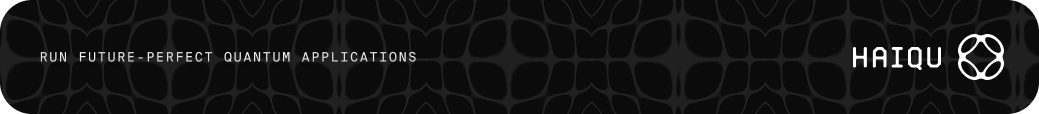